# New England — Faraday Training

Faraday is a conditional VAE over daily load profiles plus a Gaussian Mixture Model over the
joint (latent, label) space. For New England: 96-interval (15-min) profiles conditioned on 8
integer labels — state, archetype, heating_fuel, has_ev, has_pv, month, dayofweek, temp_bin —
so the GMM lives in a 16 + 8 = 24-dimensional space.

This notebook demonstrates the chain at reduced scale (minutes on CPU). The full run is
`scripts/train_ne_faraday.py` (VAE 150 epochs on all 492,750 training profiles, GMM sweep
n_components ∈ {200, 100, 400}), which writes checkpoints to `data/models/new_england/`:

| Artifact | Contents |
|---|---|
| `ne_vae.ckpt` | Lightning checkpoint of the trained FaradayVAE |
| `ne_vae_meta.json` | Feature list, per-epoch losses, run config |
| `ne_gmm_{k}.pt` | GMM buffers + feature ranges for each k in the sweep |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch

pl.seed_everything(0)

TRAIN_DIR = Path("../../data/processed/new_england/train")

N_SAMPLES = 20_000
BATCH_SIZE = 1024
VAE_EPOCHS = 5
GMM_COMPONENTS = 20
GMM_EPOCHS = 30

Seed set to 0


In [2]:
from opensynth.data_modules.ne_data_module import NEDataModule

dm = NEDataModule(
    data_path=TRAIN_DIR / "data.csv",
    stats_path=TRAIN_DIR / "mean_std.csv",
    batch_size=BATCH_SIZE,
    n_samples=N_SAMPLES,
    outlier_path=TRAIN_DIR / "outliers.csv",
)
dm.setup()
batch = next(iter(dm.train_dataloader()))
print("kwh batch:", tuple(batch["kwh"].shape))
print("features:", list(batch["features"].keys()))
assert batch["kwh"].shape[1] == 96

kwh batch: (1024, 96)
features: ['state', 'archetype', 'heating_fuel', 'has_ev', 'has_pv', 'month', 'dayofweek', 'temp_bin']


## VAE

The encoder sees the standardised 96-interval profile concatenated with the labels; the
decoder gets the 16-dim latent code plus the same labels back.

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder        │ Encoder                 │  228 K │ train │     0 │
│ 1 │ decoder        │ Decoder                 │  225 K │ train │     0 │
│ 2 │ reparametriser │ ReparametrisationModule │    544 │ train │     0 │
└───┴────────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 454 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 454 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=5` reached.


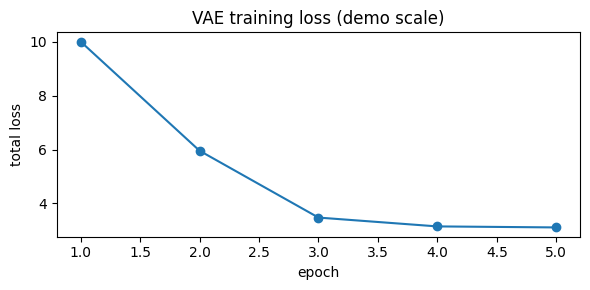

In [3]:
from opensynth.models.faraday.vae_model import FaradayVAE


class LossHistory(pl.Callback):
    def __init__(self):
        self.epoch_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("total_loss")
        if loss is not None:
            self.epoch_losses.append(float(loss))


vae = FaradayVAE(
    class_dim=len(batch["features"]),
    latent_dim=16,
    input_dim=96,
    learning_rate=1e-3,
    mse_weight=3,
)
history = LossHistory()
trainer = pl.Trainer(
    max_epochs=VAE_EPOCHS,
    accelerator="cpu",
    callbacks=[history],
    enable_checkpointing=False,
    enable_progress_bar=False,
    logger=False,
)
trainer.fit(vae, dm)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(history.epoch_losses) + 1), history.epoch_losses, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("total loss")
ax.set_title("VAE training loss (demo scale)")
plt.tight_layout()
assert history.epoch_losses[-1] < history.epoch_losses[0]

## GMM over the joint (latent, label) space

The GMM is fit on encoded latents concatenated with the integer labels. Sampling a component
then yields both a latent code and the labels it co-occurred with — which is what makes
*conditional* sampling (below) possible in closed form.

In [4]:
from opensynth.datasets.new_england.faraday_ne import NewEnglandFaradayModel

model = NewEnglandFaradayModel(
    vae_module=vae,
    n_components=GMM_COMPONENTS,
    tol=1e-3,
    max_epochs=GMM_EPOCHS,
    covariance_reg=1e-4,
)
model.train_gmm(dm=dm)
print("GMM means:", tuple(model.gmm_module.means.shape))

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


Initial prec chol: 1.602441668510437.                 Initial mean: -1.4136484861373901


/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run 

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                      ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gmm_module                │ GaussianMixtureModel        │      0 │ train │     0 │
│ 1 │ vae_module                │ FaradayVAE                  │  454 K │ train │     0 │
│ 2 │ weight_metric             │ WeightsMetric               │      0 │ train │     0 │
│ 3 │ mean_metric               │ MeansMetric                 │      0 │ train │     0 │
│ 4 │ precision_cholesky_metric │ PrecisionCholeskyMetric     │      0 │ train │     0 │
│ 5 │ covariance_metric         │ CovarianceMetric            │      0 │ train │     0 │
│ 6 │ nll                       │ NegativeLogLikelihoodMetric │      0 │ train │     0 │
└───┴───────────────────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 454 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 454 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/jeremyhaynes/.local/share/virtualenvs/OpenSynth-xJUI0V_q/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (19) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


GMM means: (20, 24)


## Conditional sampling

`sample_gmm_conditional` conditions every mixture component on a chosen label vector
(closed-form Gaussian conditioning, components reweighted by their likelihood of those
labels). Same oil-heated Connecticut single-family home, cold January weekday vs mild July
weekday — at demo scale the contrast is already directionally right; the full model sharpens
it.

Winter-cold mean: 0.2980 kWh/15min; summer-mild mean: 0.2525


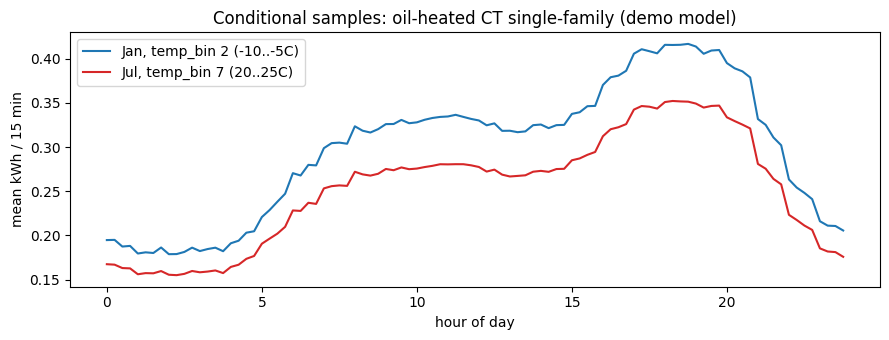

In [5]:
base = {
    "state": 0,
    "archetype": 0,
    "heating_fuel": 2,
    "has_ev": 0,
    "has_pv": 0,
    "dayofweek": 2,
}
with torch.no_grad():
    winter = model.sample_gmm_conditional({**base, "month": 1, "temp_bin": 2}, 512)
    summer = model.sample_gmm_conditional({**base, "month": 7, "temp_bin": 7}, 512)

w = dm.reconstruct_kwh(winter["kwh"]).clip(min=0).numpy()
s = dm.reconstruct_kwh(summer["kwh"]).clip(min=0).numpy()
print(f"Winter-cold mean: {w.mean():.4f} kWh/15min; summer-mild mean: {s.mean():.4f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
hours = np.arange(96) / 4
ax.plot(hours, w.mean(axis=0), color="tab:blue", label="Jan, temp_bin 2 (-10..-5C)")
ax.plot(hours, s.mean(axis=0), color="tab:red", label="Jul, temp_bin 7 (20..25C)")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean kWh / 15 min")
ax.set_title("Conditional samples: oil-heated CT single-family (demo model)")
ax.legend()
plt.tight_layout()

## Full-scale run

```
nohup pipenv run python scripts/train_ne_faraday.py > /tmp/ne_train_full.log 2>&1 &
```

Hours on CPU (Apple M4, 24 GB). A checkpoint lands after every stage — the VAE first, then one
GMM per sweep value — so partial runs are already usable by `ne_evaluation.ipynb`.